# 03. Opacus in Action - End-to-End Image Classification

Now that we understand the `PrivacyEngine` (Notebook 00), the DP-SGD loop (Notebook 01), and Model Compatibility (Notebook 02), it is time to put everything together.

In this notebook, we will train a Convolutional Neural Network (CNN) on an image dataset (FashionMNIST) from scratch with Differential Privacy. This is directly applicable to the real-world dataset framework, where you might be handling sensitive data (like MRIs or Tax data).

### What we will do:
1. Load a standard image dataset (FashionMNIST).
2. Define a CNN with `BatchNorm2d`.
3. Use `ModuleValidator` to safely rewrite the model.
4. Attach the `PrivacyEngine` and execute a DP-SGD training loop.

In [1]:
# Load the modules
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
import warnings
warnings.filterwarnings('ignore')

#### 🔧 System Utility: PyTorch Compatibility
To ensure Opacus runs smoothly with our environment's PyTorch version, we import and apply a background patch from our local utilities. This resolves a known API mismatch with Convolutional layer hooks.

In [2]:
import sys
sys.path.append('./utils')
from opacus_patch import apply_fsdp_patch

# Apply the background patch
apply_fsdp_patch()

🔧 FSDPModule dummy injected! Opacus compatibility secured.


## 1. Load the Image Data
We will use FashionMNIST. It is a 28x28 grayscale image dataset, structurally very similar to standard MNIST but slightly more complex.

In [3]:
BATCH_SIZE = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, ), (0.5, ))
])

# Download and load the dataset
train_dataset = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Print sample lengths
print(f" Training Samples\t: {len(train_dataset)}")
print(f" Testing Samples\t: {len(test_dataset)}")

 Training Samples	: 60000
 Testing Samples	: 10000


## 2. Define the CNN & Fix Compatibility
We will intentionally design a standard CNN using `BatchNorm2d`. As we learned in the previous notebook, this will break the `PrivacyEngine`. We will immediately fix it using `ModuleValidator`.

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv Block 1
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)    # <----- Incompatible Layer
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        
        # Conv Block 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)    # <----- Incompatible Layer
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        
        # FC layer
        self.fc = nn.Linear(32 * 7 * 7, 10)
        
    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
    
# 1. Initiate the model
model = SimpleCNN()

# 2. FIX THE MODEL (BatchNorm --> GroupNorm)
model = ModuleValidator.fix(model)
print("Model successfully validated and fixed! BatchNorms have been replaced.")

# Move model to GPU (if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device using: {device}")
model = model.to(device)

Model successfully validated and fixed! BatchNorms have been replaced.
Device using: cuda


## 3. Attach the Privacy Engine
Now we initialize the optimizer and wrap everything. Notice that we define `EPOCHS` early. Opacus uses the number of epochs and the batch size to properly calculate the noise distribution over time.

In [5]:
EPOCHS = 10
LR = 0.05
MAX_GRAD_NORM = 1.2

optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9)
criterion = nn.CrossEntropyLoss()

privacy_engine = PrivacyEngine()

model, optimizer, train_loader, = privacy_engine.make_private_with_epsilon(
    module = model,
    optimizer = optimizer,
    data_loader = train_loader,
    epochs = EPOCHS,
    target_epsilon = 5.0,
    target_delta = 1e-5,
    max_grad_norm = MAX_GRAD_NORM,
)

print("Privacy Engine attached using `make_private_with_epsilon`.")
print("Notice we requested a target_epsilon of 5.0. Opacus automatically calculates the required noise_multiplier.")

Privacy Engine attached using `make_private_with_epsilon`.
Notice we requested a target_epsilon of 5.0. Opacus automatically calculates the required noise_multiplier.


## 4. The DP-SGD Training Loop
Let's train the model. Because adding noise makes gradients volatile, you will likely notice the training loss fluctuating more than a standard non-DP CNN.

In [6]:
from tqdm import tqdm

# Lists to store metrics for plotting
train_losses = []
train_accs = []
epsilons = [] # Track epsilon history for dynamic analysis

def train(model, train_loader, optimizer, epoch, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    # Wrap the loader with tqdm for a dynamic progress bar
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Dynamically update the progress bar with current loss and accuracy
        progress_bar.set_postfix({
            'Loss': f"{total_loss/(progress_bar.n + 1):.4f}", 
            'Acc': f"{100.*correct/total:.2f}%"
        })

    # Calculate final epoch metrics
    epoch_loss = total_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    # 🚨 PROPER EPSILON TRACKING 🚨
    # Query the PrivacyEngine at the end of each epoch to monitor budget consumption.
    epsilon = privacy_engine.get_epsilon(1e-5)
    epsilons.append(epsilon)
    
    print(f"Epoch {epoch} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}% | Spent ε: {epsilon:.2f}")

print("Starting DP Training...")
for epoch in range(1, EPOCHS + 1):
    train(model, train_loader, optimizer, epoch, device)

Starting DP Training...


Epoch 1 | Loss: 0.7902 | Acc: 80.57% | Spent ε: 3.09


Epoch 2 | Loss: 0.8892 | Acc: 83.15% | Spent ε: 3.49


Epoch 3 | Loss: 0.9447 | Acc: 83.66% | Spent ε: 3.77


Epoch 4 | Loss: 0.9266 | Acc: 84.45% | Spent ε: 4.00


...

Epoch 6 | Loss: 0.9159 | Acc: 84.25% | Spent ε: 4.38


Epoch 7 | Loss: 0.8994 | Acc: 84.30% | Spent ε: 4.54


Epoch 8 | Loss: 0.8816 | Acc: 84.45% | Spent ε: 4.70


Epoch 9 | Loss: 0.8365 | Acc: 85.03% | Spent ε: 4.85


Epoch 10 | Loss: 0.8210 | Acc: 85.17% | Spent ε: 4.99


### Training Output & Privacy Accounting Analysis
Based on the 10-epoch training run, we can observe the distinct mechanical signatures of Differentially Private Stochastic Gradient Descent (DP-SGD):

>#### 1. The Precision of Target Budgeting (𝜖)
We utilized `make_private_with_epsilon(target_epsilon=5.0)`. Look at the `Spent ε` for Epoch 10: it landed perfectly at **4.99**. Opacus successfully reverse-engineered the exact `noise_multiplier` required to distribute the privacy budget across 10 epochs without breaching the strict 5.0 limit. 

>#### 2. Sub-Linear Privacy Leakage
Notice the growth rate of 𝜖. In Epoch 1, the model spends a massive **3.09 𝜖**. However, by Epoch 10, a full pass over the data only costs **0.14 𝜖** (growing from 4.85 to 4.99). This sub-linear curve is driven by advanced privacy accountants (like PRV or RDP). Understanding this decaying cost curve is the exact foundation required to build dynamic DP budget allocation algorithms; the earlier epochs are vastly more "expensive" than the later ones.

>#### 3. Gradient Noise and Loss Volatility
In a standard CNN, loss almost universally trends downward. In our output, the loss fluctuates erratically: it starts at `0.80`, spikes to `0.96` by Epoch 4, and drops back to `0.79` by Epoch 10. Accuracy similarly stalls around `84-85%`. This is not a bug; this is the literal cost of privacy. The Gaussian noise injected to protect individual data intentionally destabilizes the optimizer, acting as a heavy regularizer that prevents the model from perfectly fitting the training data.

## 5. Comprehensive Evaluation and Plotting

Because FashionMNIST is a multi-class dataset (10 classes), plotting an ROC curve requires a One-vs-Rest (OvR) macro-average approach. This snippet gathers the test set probabilities, calculates the strict evaluation metrics, and generates a side-by-side subplot containing the training curves and the multi-class ROC curve.


      TEST EVALUATION
Test Loss: 0.8654
Test Accuracy: 84.61%
Macro-Average AUC Score: 0.9826



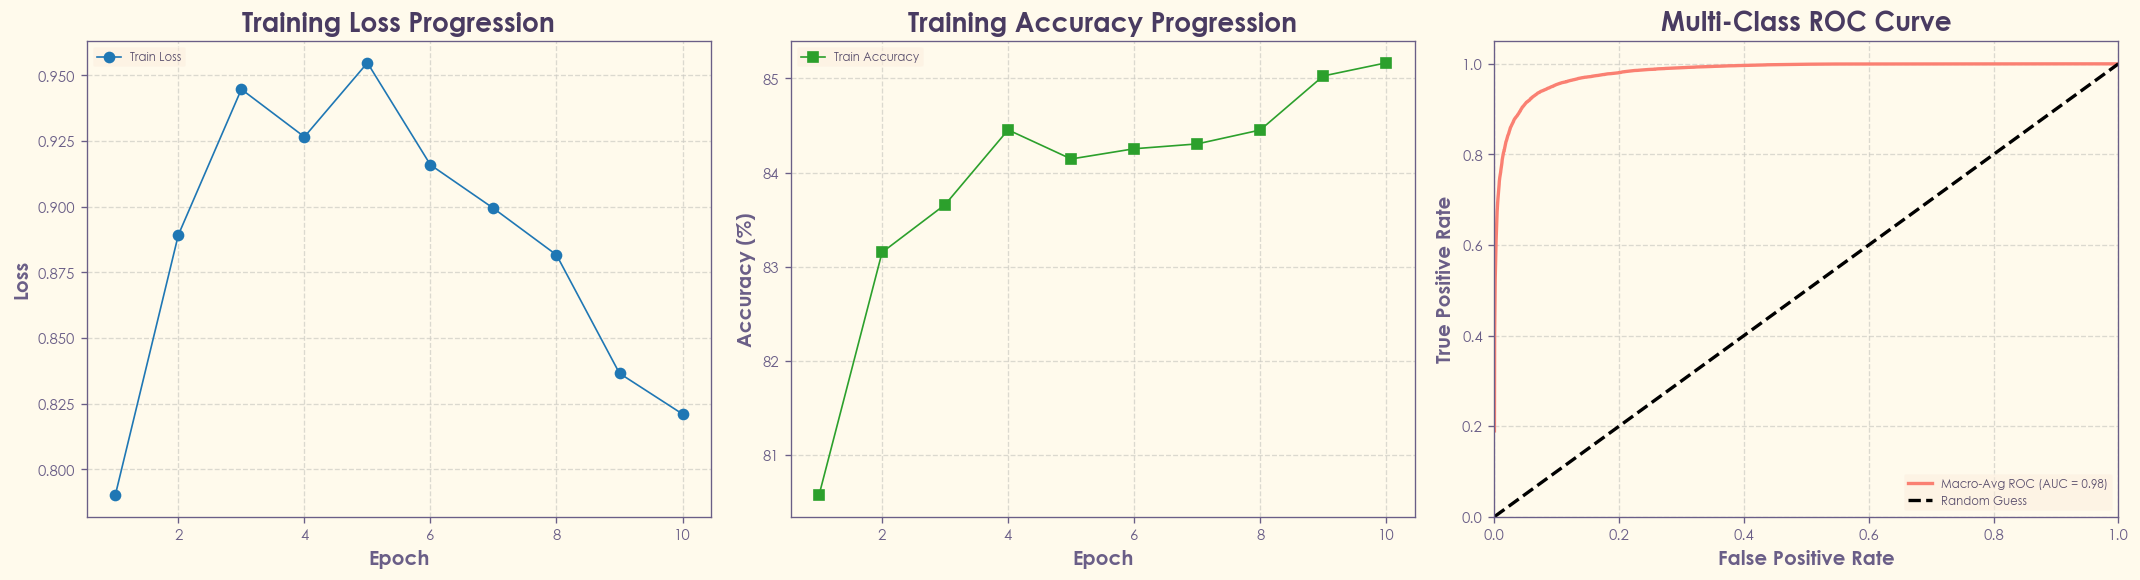

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

def evaluate_and_plot(model, test_loader, device):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item()
            
            # Apply softmax to get probabilities for AUC
            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # Store labels and probabilities for sklearn metrics
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    test_loss = test_loss / len(test_loader)
    test_acc = 100. * correct / total
    
    print("\n" + "="*30)
    print("      TEST EVALUATION")
    print("="*30)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")
    
    # --- AUC & ROC Computations ---
    # Binarize the labels for multi-class ROC calculation
    n_classes = 10
    y_test_bin = label_binarize(all_labels, classes=[i for i in range(n_classes)])
    y_probs = np.array(all_probs)
    
    # Calculate Macro-Average AUC Score
    auc_score = roc_auc_score(y_test_bin, y_probs, multi_class='ovr', average='macro')
    print(f"Macro-Average AUC Score: {auc_score:.4f}\n")
    
    # --- Plotting ---
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Loss Curve
    axs[0].plot(range(1, EPOCHS+1), train_losses, label='Train Loss', color='#1f77b4', marker='o')
    axs[0].set_title('Training Loss Progression')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].grid(True, linestyle='--', alpha=0.7)
    axs[0].legend()
    
    # 2. Accuracy Curve
    axs[1].plot(range(1, EPOCHS+1), train_accs, label='Train Accuracy', color='#2ca02c', marker='s')
    axs[1].set_title('Training Accuracy Progression')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy (%)')
    axs[1].grid(True, linestyle='--', alpha=0.7)
    axs[1].legend()
    
    # 3. Macro-Average ROC Curve
    fpr, tpr, roc_auc = dict(), dict(), dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    
    axs[2].plot(all_fpr, mean_tpr, color='salmon', lw=2, 
                label=f'Macro-Avg ROC (AUC = {auc_score:.2f})')
    axs[2].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
    axs[2].set_xlim([0.0, 1.0])
    axs[2].set_ylim([0.0, 1.05])
    axs[2].set_xlabel('False Positive Rate')
    axs[2].set_ylabel('True Positive Rate')
    axs[2].set_title('Multi-Class ROC Curve')
    axs[2].grid(True, linestyle='--', alpha=0.7)
    axs[2].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

# Execute evaluation
evaluate_and_plot(model, test_loader, device)

### Visualizing the Privacy Budget

We will be using the `epsilons` list and `EPOCHS` variable generated from the training loop.

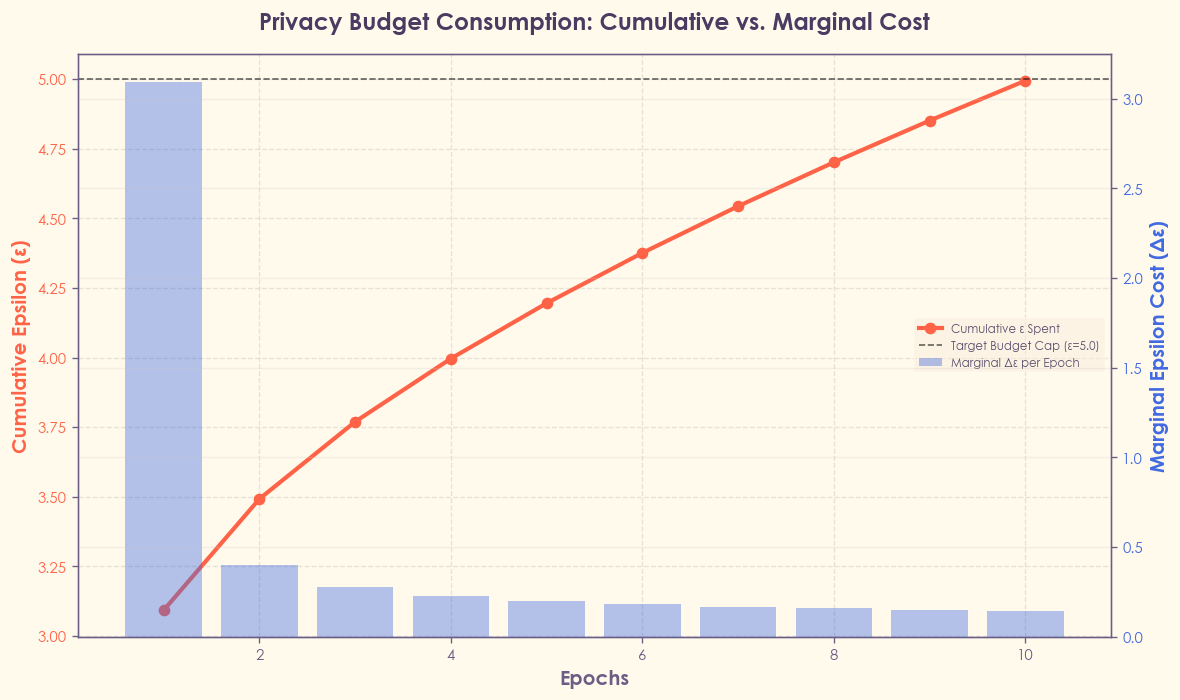

In [8]:
import matplotlib.pyplot as plt

# Calculate the marginal cost per epoch (how much epsilon was spent during just that specific epoch)
marginal_epsilons = [epsilons[0]] + [epsilons[i] - epsilons[i-1] for i in range(1, len(epsilons))]
epochs_range = range(1, len(epsilons) + 1)

fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Plot 1: Cumulative Epsilon (Left Y-Axis) ---
color = 'tomato'
ax1.set_xlabel('Epochs', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Epsilon (ε)', color=color, fontsize=12, fontweight='bold')
ax1.plot(epochs_range, epsilons, marker='o', color=color, linewidth=2.5, label='Cumulative ε Spent')
ax1.tick_params(axis='y', labelcolor=color)

# Add a dashed line for our target budget
ax1.axhline(y=5.0, color='black', linestyle='--', alpha=0.6, label='Target Budget Cap (ε=5.0)')

# --- Plot 2: Marginal Cost (Right Y-Axis) ---
ax2 = ax1.twinx()  
color = 'royalblue'
ax2.set_ylabel('Marginal Epsilon Cost (Δε)', color=color, fontsize=12, fontweight='bold')
ax2.bar(epochs_range, marginal_epsilons, color=color, alpha=0.4, label='Marginal Δε per Epoch')
ax2.tick_params(axis='y', labelcolor=color)

# --- Formatting ---
plt.title('Privacy Budget Consumption: Cumulative vs. Marginal Cost', fontsize=14, pad=15)
fig.tight_layout()
ax1.grid(True, linestyle='--', alpha=0.5)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

plt.show()

## 6. Learning from the Budget: The Sub-Linear Cost of Privacy

The plot above reveals a fundamental characteristic of modern Differential Privacy accountants (like Rényi Differential Privacy or PRV) and is the cornerstone of **dynamic budget allocation**:

### The Marginal Cost of Training Decays
Look at the blue bars (Marginal Δε). 
* **Epoch 1** cost a massive `~3.09 ε`.
* **Epoch 2** cost only `~0.40 ε`.
* **Epoch 10** cost a mere `~0.14 ε`.

In DP-SGD, **privacy does not leak linearly**. The first time the model looks at the data, it extracts a huge amount of novel information, costing a large portion of your privacy budget. However, as the model repeatedly views the **_same_ data with newly added Gaussian noise**, it learns progressively less novel (identifiable) information about individual patients. The advanced mathematical accountants recognize this overlap and charge you less and less ε for subsequent epochs.

### Implications for Dynamic Budgeting
If you are designing an algorithm to dynamically allocate budgets during training, this decay curve changes your strategy entirely:
1. **Early Halting is Expensive:** If you stop training at Epoch 2 to "save budget," you have already spent ~70% of your total target. You sacrificed utility without saving much privacy.
2. **"Free" Late Epochs:** If you reach Epoch 8 and notice the model is close to converging, you can safely run a few extra epochs. Because the marginal cost is so low at the end of the curve (e.g., 0.14 ε), those extra epochs are practically "free" on the privacy budget but could yield vital accuracy gains for a sensitive model, like medical AI.

### 🎉 Summary
We have successfully trained, evaluated, and analyzed a DP-compliant CNN on an image dataset from start to finish! 

**Key Takeaways:**
1. **Target-Driven Budgets:** We used `make_private_with_epsilon()` instead of `make_private()`. This allows us to define a strict target budget (e.g., $\epsilon=5.0$), and Opacus automatically calculates the exact `noise_multiplier` needed to hit that budget over the specified `EPOCHS`.
2. **Real-time Refactoring:** We successfully applied the `ModuleValidator` to automatically rewrite incompatible layers (like `BatchNorm2d`) before wrapping the model.
3. **System Compatibility:** We cleanly navigated PyTorch/Opacus version mismatches by injecting a dummy `FSDPModule` via an external utility script (`opacus_patch.py`), keeping our core research notebook uncluttered.
4. **Diagnostic Evaluation:** We established a robust post-test evaluation pipeline using multi-class Macro-Average ROC curves and AUC scores. These metrics are critical for evaluating medical AI models where raw accuracy is often insufficient.
5. **The Sub-Linear Cost of Privacy:** By actively tracking and plotting the epoch-by-epoch $\epsilon$ spend, we visualized how the marginal cost of training decays over time. Understanding this curve is the absolute foundation for research in dynamic DP budget allocation.

***

In **Notebook 04**, we will tackle one of the biggest bottlenecks in DP-SGD: GPU Memory limitations. Because DP-SGD calculates per-sample gradients, it is incredibly memory-hungry. We will learn how to use Opacus's `BatchMemoryManager` to simulate large virtual batches without running out of VRAM.